<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 5 Multiple Linear Regression - Polynomial Regression</b></center>    
<pre>    

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import sklearn

## Step 2. Import the dataset

In [2]:
df = pd.read_csv("50_Startups.csv")

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [4]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [5]:
x=df[['R&D Spend','Administration','Marketing Spend','State']]
y=df['Profit']
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [6]:
x1=pd.get_dummies(x,columns=['State'],drop_first=True)
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [7]:
x1=x1.astype(int)
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349,136897,471784,0,1
1,162597,151377,443898,0,0
2,153441,101145,407934,1,0
3,144372,118671,383199,0,1
4,142107,91391,366168,1,0
5,131876,99814,362861,0,1
6,134615,147198,127716,0,0
7,130298,145530,323876,1,0
8,120542,148718,311613,0,1
9,123334,108679,304981,0,0


## Step 6 . Dummy variable trap

In [ ]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y,train_size=0.8,random_state=42)


## Step 8  Import LinearRegression model from linear_model family 

In [9]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

## Step 9  Fit the data

In [10]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.81, -0.07, 0.03,938.75, 6.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['R&D Spend','Administration','Marketing Spend','State_Florida', 'State_New York']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.403e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## Step 10  Predict the data

In [11]:
y_predict=model.predict(x_test)

## Step 11  Display Result

In [12]:
# y_test and y_predict
print(y_predict)
print(y_test)

[126362.93252171  84608.52579874  99677.45007307  46357.54709785
 128750.69322711  50912.79650819 109741.00850976 100643.01925189
  97598.94761148 113097.03975177]
13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
Name: Profit, dtype: float64


In [13]:
import matplotlib.pyplot as plt

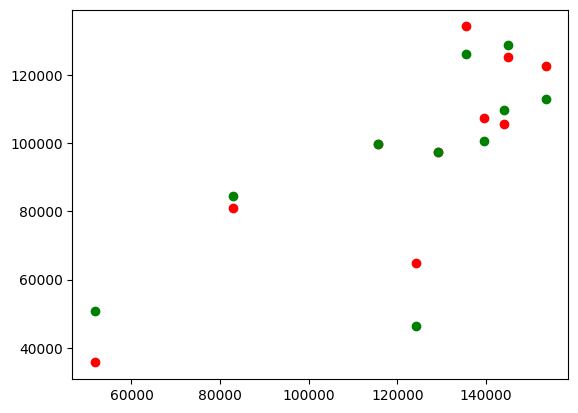

In [14]:
plt.scatter(x_test['Administration'],y_test,c='r')
plt.scatter(x_test['Administration'],y_predict,c='g')

# Importing the libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Importing the libraries

In [16]:
df = pd.read_csv("Position_Salaries.csv")

In [17]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


# Plot the data using scatter plot

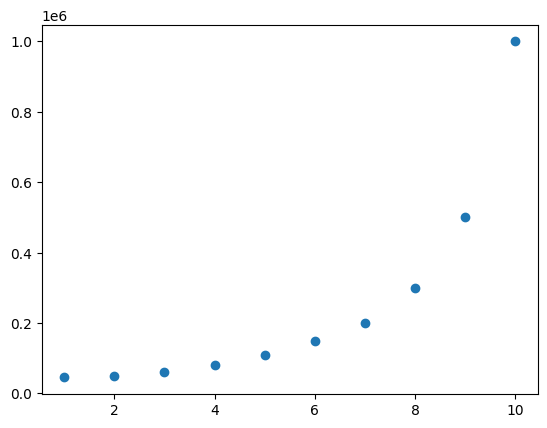

In [18]:
plt.scatter(df['Level'],df['Salary'])

In [19]:
#x=df.iloc[::,1:2:]
x=df[['Level']]
y=df['Salary']
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# Splitting the dataset into the Training set and Test set

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=7)

,Level
2,3
1,2
9,10
7,8
3,4
6,7
4,5


# Fitting Linear Regression to the dataset

In [21]:
model=LinearRegression()

In [22]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[98994.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Level']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.944e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


# Predict the x_test using Linear Model

In [23]:
y_predict=model.predict(x_test)

# Visualising the Linear Regression results

In [24]:
print(y_test)
print(y_predict)

8    500000
5    150000
0     45000
Name: Salary, dtype: int64
[ 596551.72413793  299568.96551724 -195402.29885057]


array([ 596551.72413793,  299568.96551724, -195402.29885057])

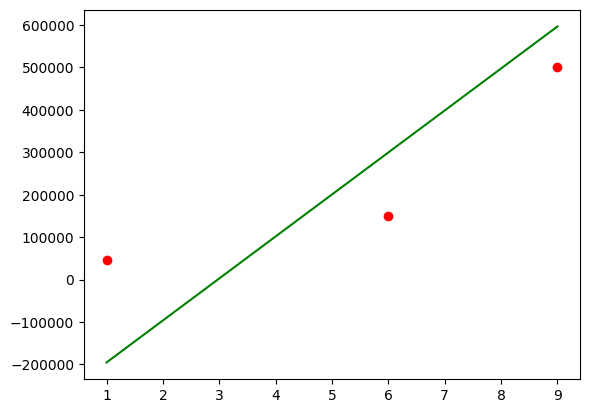

In [25]:
plt.scatter(x_test['Level'],y_test,c='r')
plt.plot(x_test['Level'],y_predict,c='g')

In [26]:
from sklearn.metrics import mean_squared_error

In [27]:
mean_squared_error(y_test,y_predict)

29828792057.515324

# Fitting Polynomial Regression to the dataset

## import  PolynomialFeatures

In [28]:
from sklearn.preprocessing import PolynomialFeatures

## create PolynomialFeatures of degree 4

In [29]:
poly=PolynomialFeatures(degree=4)

## Apply fit_transform to features

In [30]:
x1=poly.fit_transform(x_train)

## View new  Features

In [31]:
x1

array([[1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01],
       [1.000e+00, 1.000e+01, 1.000e+02, 1.000e+03, 1.000e+04],
       [1.000e+00, 8.000e+00, 6.400e+01, 5.120e+02, 4.096e+03],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02],
       [1.000e+00, 7.000e+00, 4.900e+01, 3.430e+02, 2.401e+03],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02, 6.250e+02]])

## Fitting Polynomial Regression to the dataset

In [32]:
model1=LinearRegression()

In [33]:
model1.fit(x1,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-307772.62, 114584.09, -16967.85, 925.67]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.299e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[8953.14, 106.77, 2.89, 0.08, 0. ]"


# Create Grid for higher resolution and smoother curve

# Predict the x_test using Polynomial Regression

In [34]:
x_test

,Level
8,9
5,6
0,1


In [36]:
y1=poly.fit_transform(x_test)
y_poly_predict=model1.predict(y1)
y1
y_poly_predict

array([545011.93317436, 142897.3747016 , 120661.89339688])

# Visualising the Linear Regression results

In [37]:
y_test

8    500000
5    150000
0     45000
Name: Salary, dtype: int64

In [38]:
y_predict

array([ 596551.72413793,  299568.96551724, -195402.29885057])

In [39]:
y_poly_predict

array([545011.93317436, 142897.3747016 , 120661.89339688])

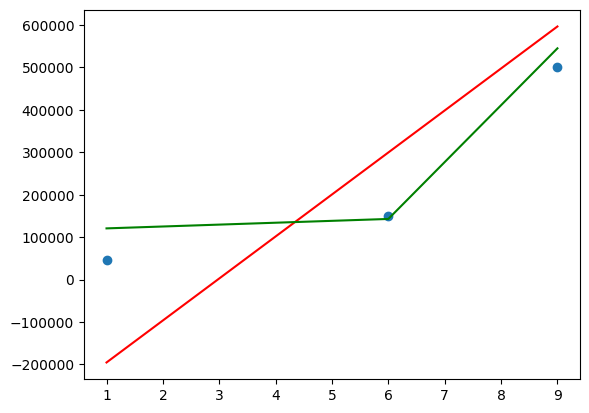

In [42]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_predict,c="r")
plt.plot(x_test,y_poly_predict,c="g")


In [43]:
import numpy as np

In [44]:
new_x = np.arange(1,10,0.1).reshape(-1,1)

In [45]:
new_x

array([[1. ],
       [1.1],
       [1.2],
       [1.3],
       [1.4],
       [1.5],
       [1.6],
       [1.7],
       [1.8],
       [1.9],
       [2. ],
       [2.1],
       [2.2],
       [2.3],
       [2.4],
       [2.5],
       [2.6],
       [2.7],
       [2.8],
       [2.9],
       [3. ],
       [3.1],
       [3.2],
       [3.3],
       [3.4],
       [3.5],
       [3.6],
       [3.7],
       [3.8],
       [3.9],
       [4. ],
       [4.1],
       [4.2],
       [4.3],
       [4.4],
       [4.5],
       [4.6],
       [4.7],
       [4.8],
       [4.9],
       [5. ],
       [5.1],
       [5.2],
       [5.3],
       [5.4],
       [5.5],
       [5.6],
       [5.7],
       [5.8],
       [5.9],
       [6. ],
       [6.1],
       [6.2],
       [6.3],
       [6.4],
       [6.5],
       [6.6],
       [6.7],
       [6.8],
       [6.9],
       [7. ],
       [7.1],
       [7.2],
       [7.3],
       [7.4],
       [7.5],
       [7.6],
       [7.7],
       [7.8],
       [7.9],
       [8. ],
      

In [46]:
y_all = model1.predict(poly.fit_transform(new_x))

In [47]:
y_all

array([120661.89339688, 108760.53554088,  98165.57379032,  88800.74954247,
        80592.02580449,  73467.58719344,  67357.83993627,  62195.4118698 ,
        57915.15244079,  54454.13270585,  51751.64533151,  49749.20459418,
        48390.54638018,  47621.62818571,  47390.62911686,  47647.94988962,
        48346.21282989,  49440.26187343,  50887.16256591,  52646.20206291,
        54678.88912988,  56948.95414218,  59422.34908504,  62067.24755362,
        64854.04475294,  67755.35749793,  70746.02421342,  73803.10493411,
        76905.88130462,  80035.85657944,  83176.75562298,  86314.52490952,
        89437.33252325,  92535.56815824,  95601.84311846,  98630.99031778,
       101620.06427996, 104568.34113864, 107477.31863737, 110350.7161296 ,
       113194.47457865, 116016.75655775, 118827.94625002, 121640.64944847,
       124469.69355601, 127332.12758545, 130247.22215947, 133236.46951067,
       136323.58348153, 139534.49952441, 142897.3747016 , 146442.58768526,
       150202.73875744, 1

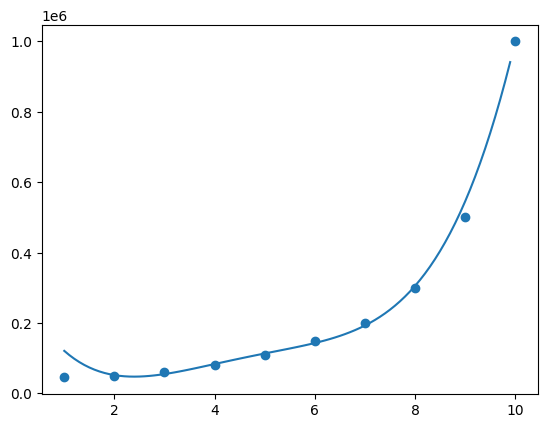

In [48]:
plt.scatter(x,y)
plt.plot(new_x,y_all)